Tổng số mẫu: 200
Phát hiện được bảng: 182 (91.0%)
Không phát hiện được: 18 (9.0%)
Accuracy trung bình: 67.50%
Accuracy trung vị: 80.46%
Thời gian trung bình: 8.74s


/var/folders/pc/wtsv3z5s0j5bx006fg66b6mr0000gn/T/ipykernel_90012/3371458733.py:78: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax4.scatter(df.loc[~detected_mask, 'time_sec'],


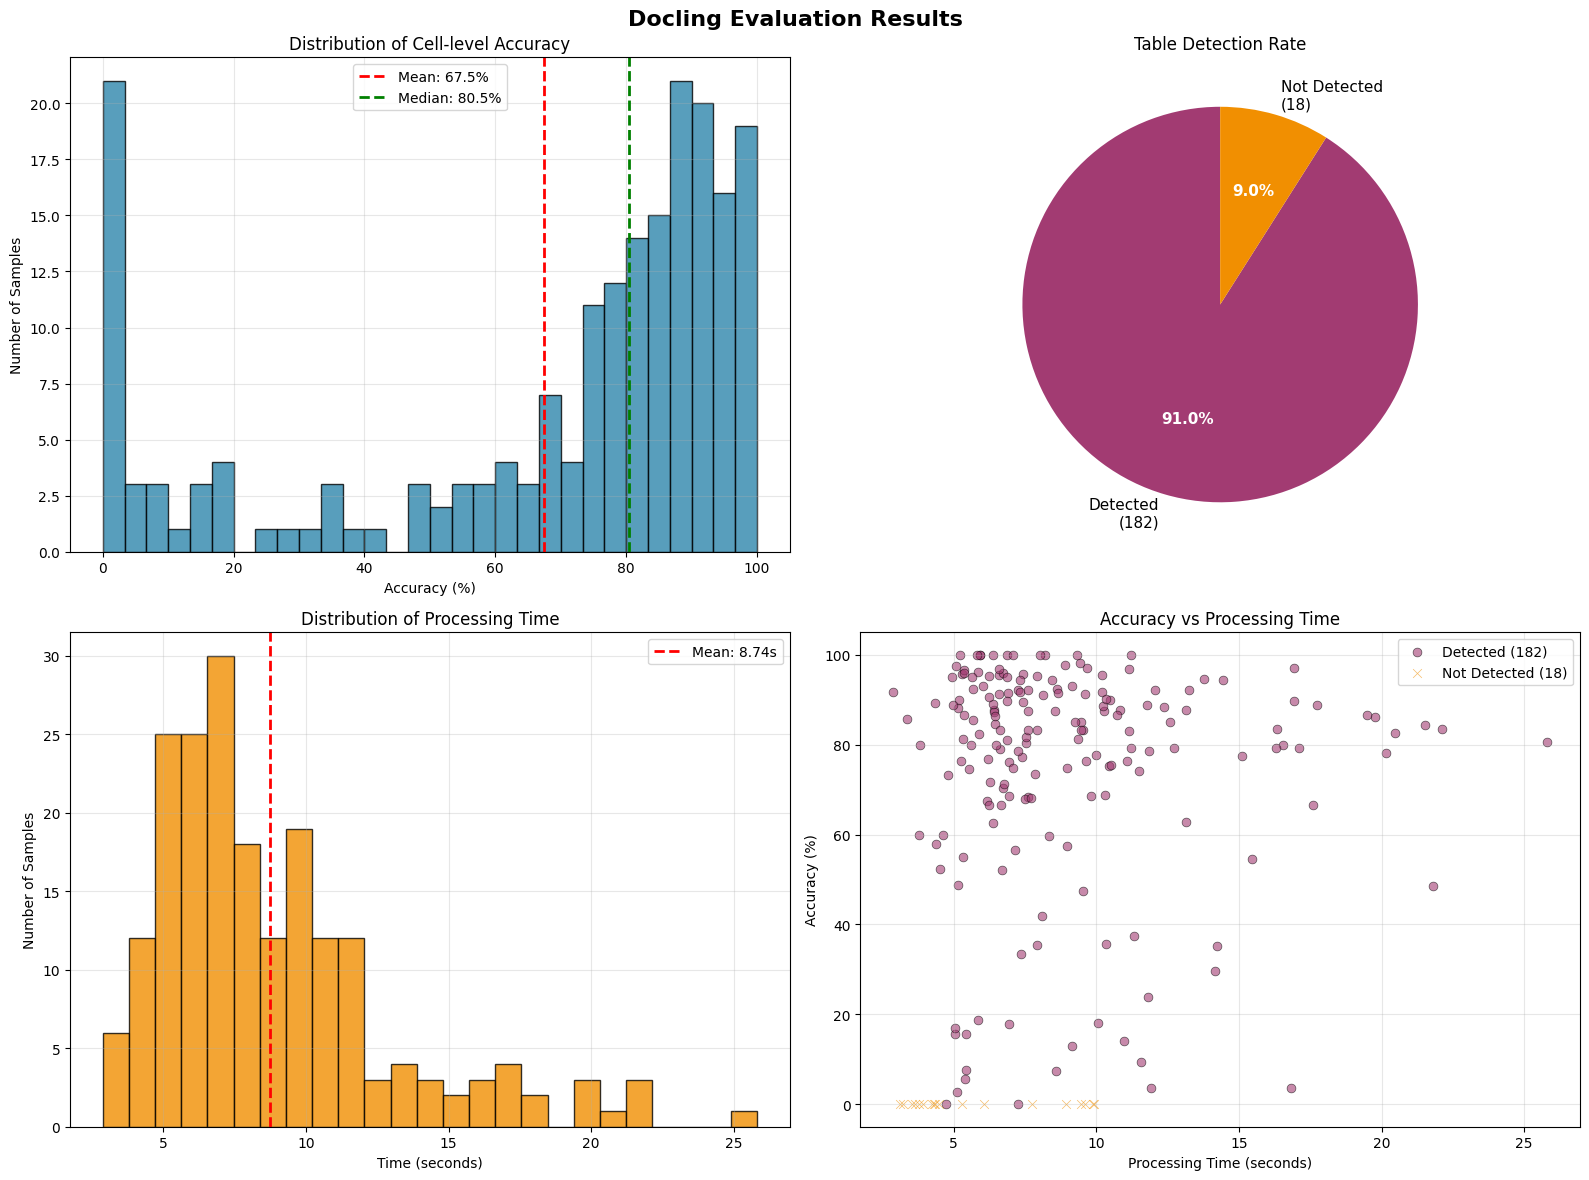


✅ Đã lưu docling_eval_summary.png và docling_summary_stats.csv
                                   Metric Value
                            Total Samples   200
                          Tables Detected   182
                      Tables Not Detected    18
                       Detection Rate (%)  91.0
                        Mean Accuracy (%) 67.50
                      Median Accuracy (%) 80.46
                            Mean Time (s)  8.74
                             Max Time (s) 25.81
                             Min Time (s)  2.88
               Samples with 100% Accuracy    11
      Samples with 0% Accuracy (no table)    18
Samples with 0% Accuracy (table detected)     2


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Đọc dữ liệu ─────────────────────────────────────────────
DOC_CSV = "/Users/macbookpro14m1pro/Desktop/RagTable/python/notebooks/docling_eval_results.csv"
df = pd.read_csv(DOC_CSV)

# Thống kê cơ bản
total = len(df)
detected = (df['num_tables'] > 0).sum()
not_detected = (df['num_tables'] == 0).sum()
mean_acc = df['accuracy'].mean()
median_acc = df['accuracy'].median()
mean_time = df['time_sec'].mean()

print(f"Tổng số mẫu: {total}")
print(f"Phát hiện được bảng: {detected} ({detected/total*100:.1f}%)")
print(f"Không phát hiện được: {not_detected} ({not_detected/total*100:.1f}%)")
print(f"Accuracy trung bình: {mean_acc:.2f}%")
print(f"Accuracy trung vị: {median_acc:.2f}%")
print(f"Thời gian trung bình: {mean_time:.2f}s")

# ── Vẽ biểu đồ ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Docling Evaluation Results', fontsize=16, fontweight='bold')

# Màu sắc
color_main = '#2E86AB'
color_detected = '#A23B72'
color_not_detected = '#F18F01'

# 1. Histogram accuracy
ax1 = axes[0, 0]
ax1.hist(df['accuracy'], bins=30, color=color_main, edgecolor='black', alpha=0.8)
ax1.axvline(mean_acc, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_acc:.1f}%')
ax1.axvline(median_acc, color='green', linestyle='--', linewidth=2, label=f'Median: {median_acc:.1f}%')
ax1.set_xlabel('Accuracy (%)')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Distribution of Cell-level Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Pie chart: Phát hiện vs Không phát hiện
ax2 = axes[0, 1]
sizes = [detected, not_detected]
labels = [f'Detected\n({detected})', f'Not Detected\n({not_detected})']
colors_pie = [color_detected, color_not_detected]
wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=colors_pie,
                                     autopct='%1.1f%%', startangle=90,
                                     textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Table Detection Rate')

# 3. Histogram thời gian xử lý
ax3 = axes[1, 0]
ax3.hist(df['time_sec'], bins=25, color='#F18F01', edgecolor='black', alpha=0.8)
ax3.axvline(mean_time, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_time:.2f}s')
ax3.set_xlabel('Time (seconds)')
ax3.set_ylabel('Number of Samples')
ax3.set_title('Distribution of Processing Time')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Accuracy theo thời gian (scatter, tô màu detected/not)
ax4 = axes[1, 1]
detected_mask = df['num_tables'] > 0

# Scatter cho detected
ax4.scatter(df.loc[detected_mask, 'time_sec'],
            df.loc[detected_mask, 'accuracy'],
            alpha=0.6, c=color_detected, label=f'Detected ({detected})',
            edgecolors='black', linewidth=0.5, s=40)

# Scatter cho not detected (accuracy = 0)
ax4.scatter(df.loc[~detected_mask, 'time_sec'],
            df.loc[~detected_mask, 'accuracy'],
            alpha=0.6, c=color_not_detected, label=f'Not Detected ({not_detected})',
            edgecolors='black', linewidth=0.5, s=40, marker='x')

ax4.set_xlabel('Processing Time (seconds)')
ax4.set_ylabel('Accuracy (%)')
ax4.set_title('Accuracy vs Processing Time')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('docling_eval_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Lưu file thống kê bổ sung ──────────────────────────────
# Tạo summary riêng cho báo cáo
summary = pd.DataFrame({
    'Metric': ['Total Samples', 'Tables Detected', 'Tables Not Detected',
               'Detection Rate (%)', 'Mean Accuracy (%)', 'Median Accuracy (%)',
               'Mean Time (s)', 'Max Time (s)', 'Min Time (s)',
               'Samples with 100% Accuracy', 'Samples with 0% Accuracy (no table)',
               'Samples with 0% Accuracy (table detected)'],
    'Value': [total, detected, not_detected,
              f"{detected/total*100:.1f}", f"{mean_acc:.2f}", f"{median_acc:.2f}",
              f"{mean_time:.2f}", f"{df['time_sec'].max():.2f}", f"{df['time_sec'].min():.2f}",
              (df['accuracy'] == 100).sum(),
              (df['num_tables'] == 0).sum(),
              ((df['num_tables'] > 0) & (df['accuracy'] == 0)).sum()]
})
summary.to_csv('docling_summary_stats.csv', index=False)
print("\n✅ Đã lưu docling_eval_summary.png và docling_summary_stats.csv")
print(summary.to_string(index=False))